# Loan Default Risk Analytics

## Exploratory Data Analysis, Statistical Testing & Predictive Modeling

### Business Problem

Financial institutions process thousands of loan applications every day. Approving loans without accurately assessing borrower risk can lead to increased default rates and financial losses. Conversely, rejecting creditworthy applicants may reduce business opportunities.

This project analyzes borrower demographics, financial attributes, and credit history to identify key factors associated with loan defaults. It combines exploratory data analysis, statistical testing, feature engineering, and machine learning to support data-driven lending decisions.

---

### Project Objectives

- Perform comprehensive data quality assessment and preprocessing.
- Explore borrower characteristics and loan patterns.
- Identify significant factors influencing loan defaults through statistical analysis.
- Engineer meaningful features to improve predictive performance.
- Build and compare multiple machine learning models.
- Generate actionable business recommendations for credit risk management.

---

**Tools & Technologies**

Python • Pandas • NumPy • Matplotlib • Seaborn • Scikit-learn • XGBoost • SciPy

# Dataset Overview

This project uses a loan applicant dataset containing demographic, financial, and credit history information. The objective is to analyze factors influencing loan default and build predictive models for credit risk assessment.

## Dataset Summary

| Attribute | Description |
|-----------|-------------|
| Training Records | 35,999 |
| Test Records | 9,001 |
| Predictor Variables | 13  |
| Target Variable | `loan_status` |
|Analytics Domain | Banking / Credit Risk Analytics
|Machine Learning Task | Binary Classification


---

## Feature Categories

### Applicant Information
- Age
- Income
- Employment Experience
- Home Ownership

### Loan Information
- Loan Amount
- Loan Intent
- Interest Rate
- Loan Percent Income

### Credit Information
- Credit History Length
- Credit Score
- Previous Loan Defaults

---

## Target Variable

**loan_status**

- **0** → Non-Default
- **1** → Default

The target variable indicates whether a borrower defaulted on the loan and serves as the prediction target for this project.

## 1. Import Required Libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",None)

## 2. Data Loading

In [2]:
train=pd.read_csv(r"C:\Users\SAHITHI VITTAL\Documents\Projects\Loan_Default_Prediction\data\train.csv")
test=pd.read_csv(r"C:\Users\SAHITHI VITTAL\Documents\Projects\Loan_Default_Prediction\data\test.csv")

## 3. Dataset Understanding

In [3]:
#Display dataset dimensions
print("Training Dataset Shape :", train.shape)
print("Testing Dataset Shape  :", test.shape)

#Display first five records
print("\nTraining Dataset Preview")
display(train.head())

Training Dataset Shape : (35999, 14)
Testing Dataset Shape  : (9001, 14)

Training Dataset Preview


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [4]:
#Display dataset information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35999 entries, 0 to 35998
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      35999 non-null  int64  
 1   person_gender                   35999 non-null  object 
 2   person_education                35999 non-null  object 
 3   person_income                   35999 non-null  int64  
 4   person_emp_exp                  35999 non-null  int64  
 5   person_home_ownership           35999 non-null  object 
 6   loan_amnt                       35999 non-null  int64  
 7   loan_intent                     35999 non-null  object 
 8   loan_int_rate                   35999 non-null  float64
 9   loan_percent_income             35999 non-null  float64
 10  cb_person_cred_hist_length      35999 non-null  int64  
 11  credit_score                    35999 non-null  int64  
 12  previous_loan_defaults_on_file  

### Key Observations

- The dataset contains **35,999 loan records** and **13 Features**, including the target variable (`loan_status`).
- The dataset consists of **9 numerical**, **5 categorical** variables.
- Features includes customer demographics, financial information, credit history, and loan details.

In [5]:
#Display summary statistics
train.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,35999.000000,3.599900e+04,35999.000000,35999.000000,35999.000000,35999.000000,35999.000000,35999.000000,35999.00000
mean,27.756104,8.078450e+04,5.492708,9547.586572,10.962231,0.137667,5.836412,632.813995,0.19745
std,6.257207,7.377958e+04,6.261994,6285.654364,3.021927,0.085669,4.007652,50.456070,0.39808
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.00000
25%,23.000000,4.787750e+04,1.000000,5000.000000,8.490000,0.070000,3.000000,602.000000,0.00000
50%,26.000000,6.754500e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.00000
75%,30.000000,9.682450e+04,8.000000,12000.000000,12.990000,0.190000,8.000000,670.000000,0.00000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.00000


### Key Observations
* Applicants are generally young adults, with a median age of 26 years and an average age of approximately 28 years.
* The average annual income is approximately 80,785, while the median income is 67,545, suggesting a right-skewed income distribution influenced by high-income applicants.
* Borrowers request an average loan amount of approximately 9,548 at an average interest rate of 10.96%, indicating a moderate lending portfolio.
* The average credit score is 633, indicating that the dataset contains borrowers across a broad range of credit profiles.
* The maximum values for age, income, and employment experience appear unusually high, suggesting the presence of potential outliers that should be investigated during data quality assessment.

## 4.Data Quality Check

In [6]:
#Check null values
train.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
# Check for missing values
missing_values = train.isnull().sum()

print("Missing Values in Each Column")
print(missing_values)

print(f"\nTotal Missing Values: {missing_values.sum()}")

Missing Values in Each Column
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

Total Missing Values: 0


* No missing values were found in the dataset. Therefore, no imputation is required before further analysis.

In [8]:
#Check Duplicates
train[train.duplicated()]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


* No duplicate records were found in the dataset.

## 5.Exploratory Data Analysis
### 5.1 Target Varaiable Analysis

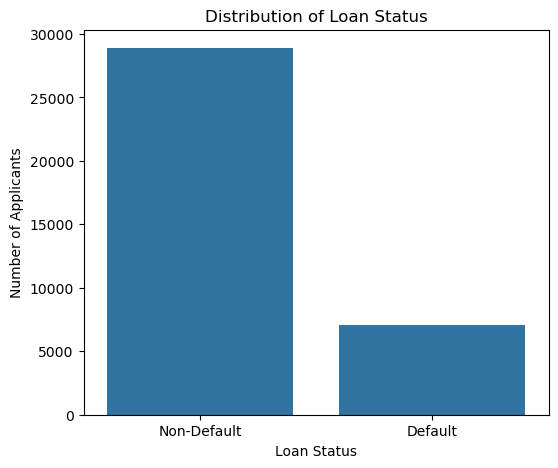

In [9]:
#class distribution
plt.figure(figsize=(6,5))

sns.countplot(data=train, x='loan_status')

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.xticks([0,1],["Non-Default","Default"])

plt.show()

In [10]:
#percentage distribution
loan_distribution = train['loan_status'].value_counts(normalize=True).mul(100).round(2)
display(loan_distribution)

loan_status
0    80.26
1    19.74
Name: proportion, dtype: float64

### Observations
- Approximately **19.74%** of applicants defaulted on their loans, while **80.26%** did not.
- The target variable is moderately imbalanced, which should be considered during model development and evaluation.

### 5.2 Univariate Analysis

Univariate analysis examines the distribution of individual variables to understand their characteristics, identify dominant categories, and detect potential anomalies.

In [11]:
#Numerical
num_cols=train.select_dtypes(include=np.number).columns
num_cols=['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']
len(num_cols)

8

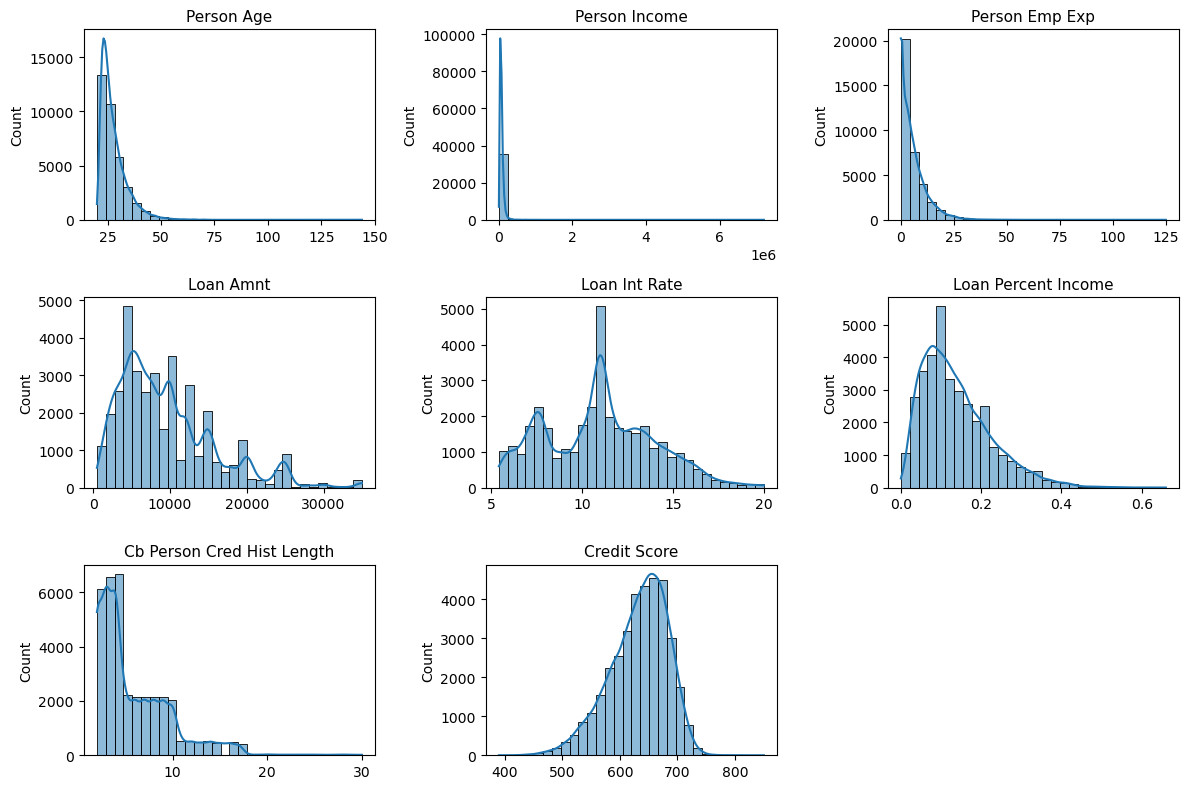

In [12]:
# Distribution of numerical variables
nrows = 3
ncols = 3
plt.figure(figsize=(12, 8))

for idx, col in enumerate(num_cols, start=1):
    plt.subplot(nrows, ncols, idx)

    sns.histplot(data=train,x=col,bins=30,kde=True )

    plt.title(f"{col.replace('_', ' ').title()}", fontsize=11)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Key Observations

- Most borrowers are aged **20–35 years**.
- Income is positively skewed with a few high-income outliers.
- Most loans are for lower loan amounts.
- Credit scores are mostly between **600 and 700**.
- Potential outliers exist in age, income, and employment experience.

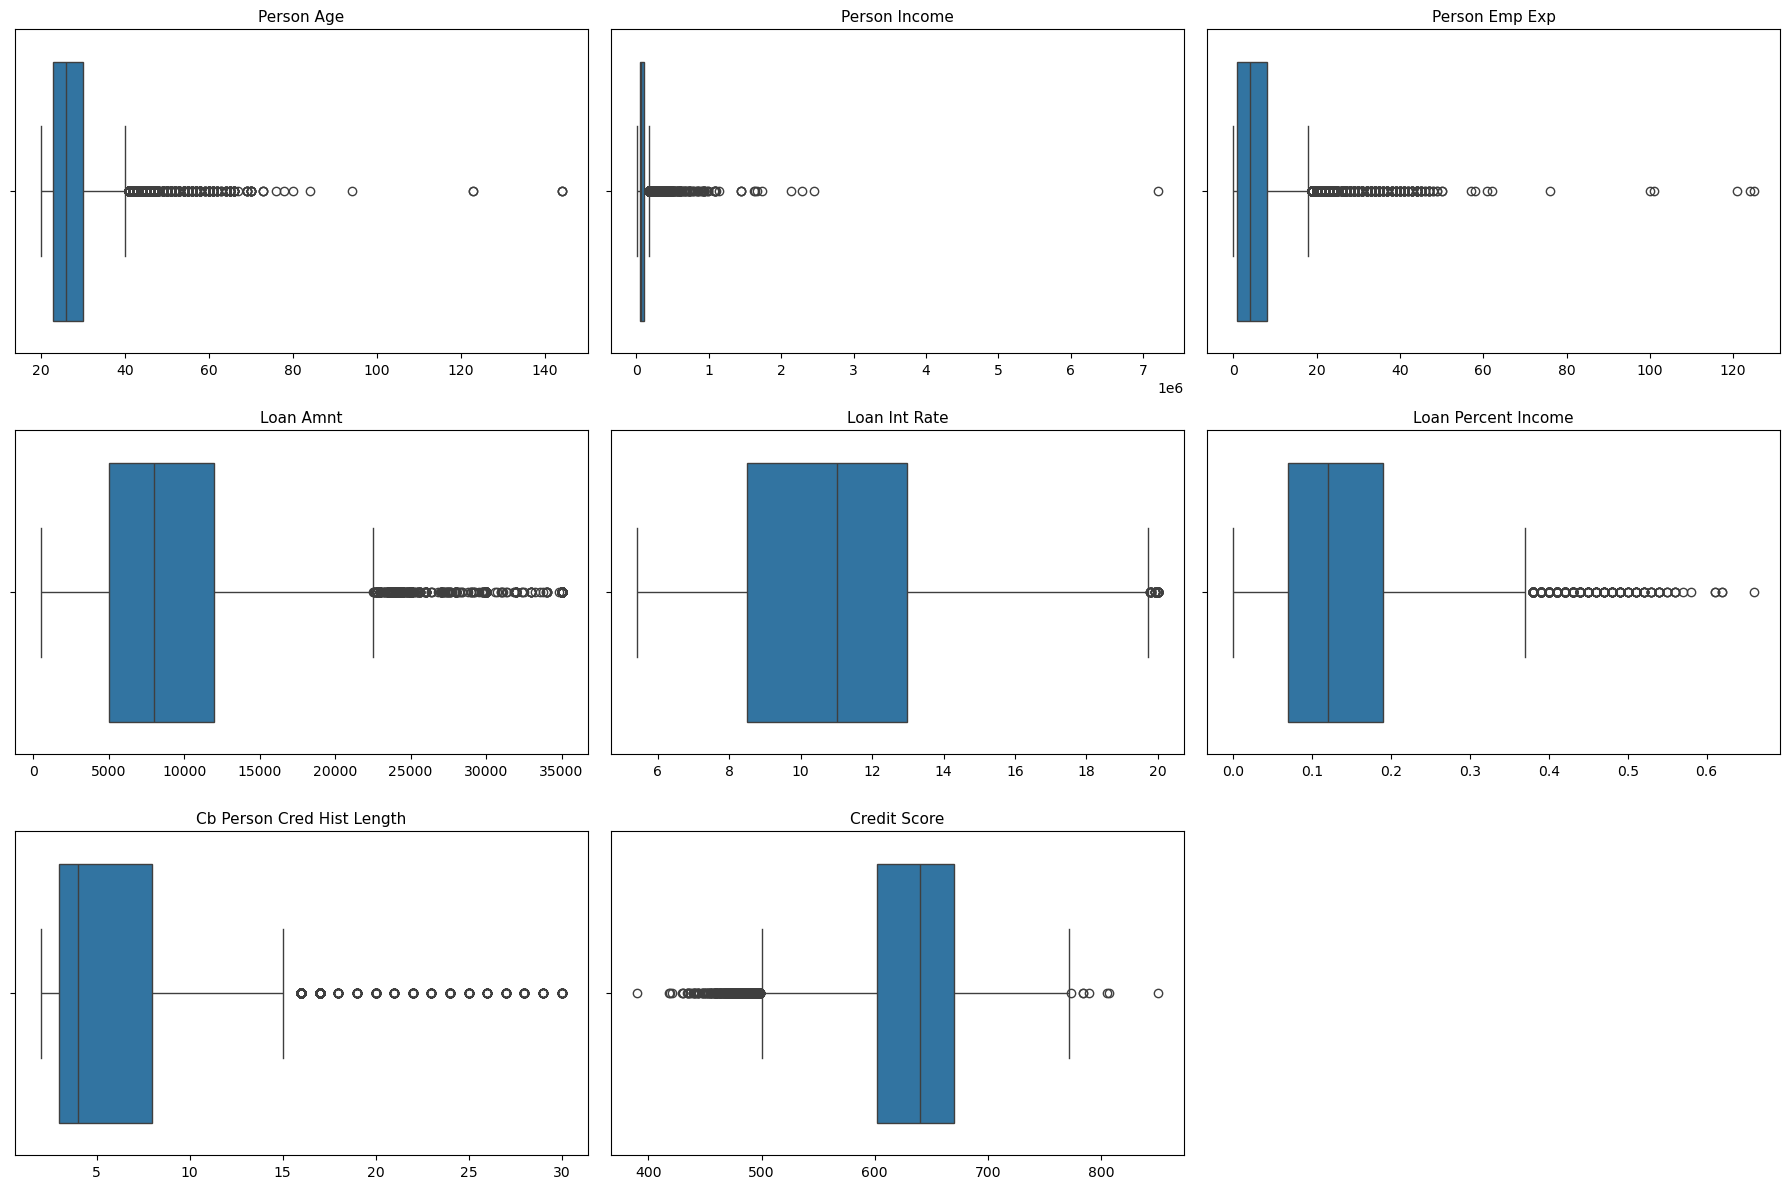

In [13]:
# Boxplots for numerical variables
nrows = 3
ncols = 3

plt.figure(figsize=(18, 12))

for idx, col in enumerate(num_cols, start=1):
    plt.subplot(nrows, ncols, idx)
    sns.boxplot(data=train, x=col)
    plt.title(col.replace("_", " ").title(), fontsize=11)
    plt.xlabel("")

plt.tight_layout()
plt.show()

### Key Observations

- Age, income, and employment experience contain notable outliers.
- Loan amount, loan percentage of income, credit history length, and credit score also show a few extreme observations.
- These outliers will be investigated further before model development.

In [14]:
cat_cols=train.select_dtypes(exclude=np.number).columns
len(cat_cols)

5

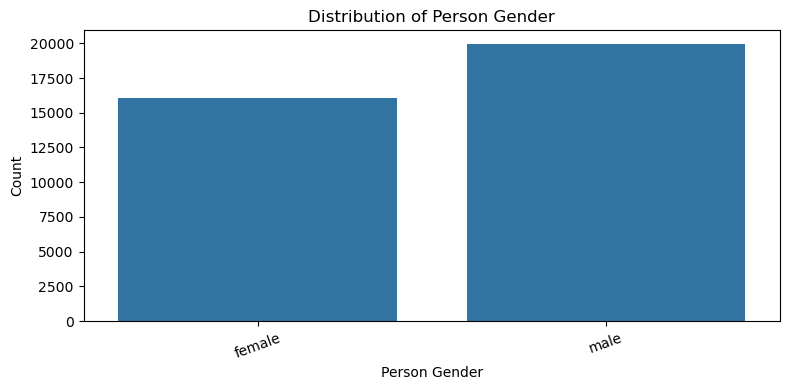

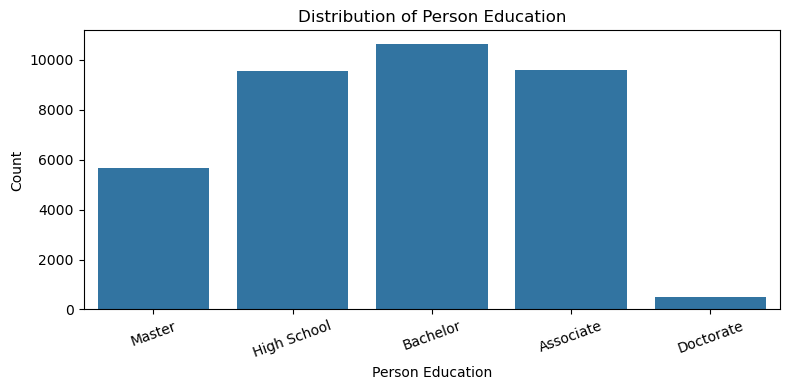

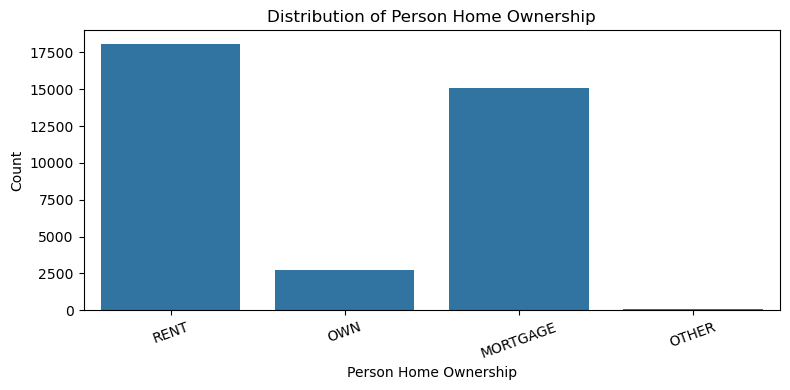

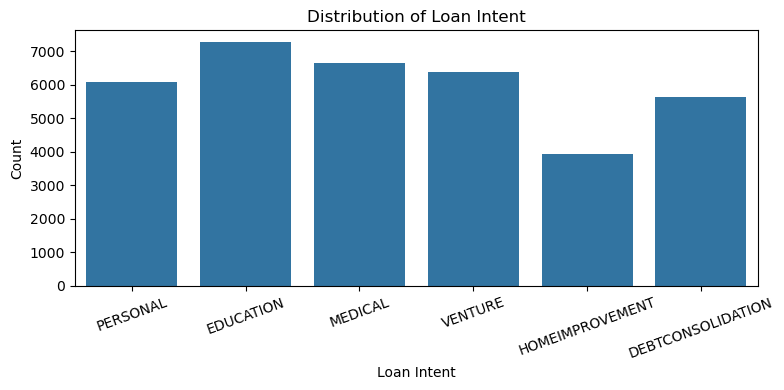

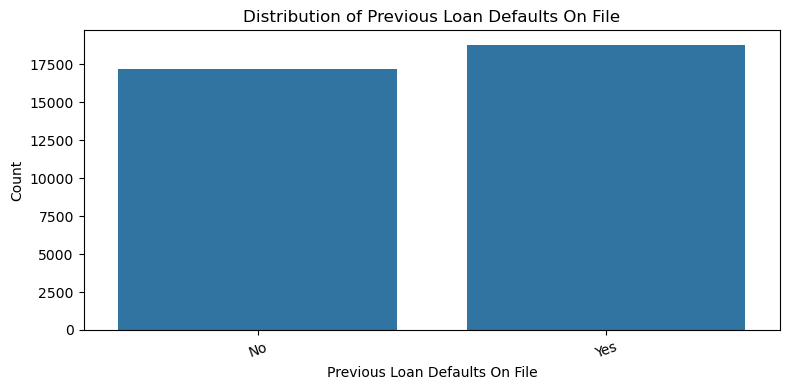

In [15]:
# Distribution of categorical variables
for col in cat_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(data=train, x=col)

    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Count")

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

### Key Observations

- Male applicants slightly outnumber female applicants.
- Bachelor's, Associate, and High School are the most common education levels among borrowers.
- Most applicants either rent or have a mortgage, while very few fall into the "Other" home ownership category.
- Education, Medical, and Venture are the most common loan purposes.
- Applicants with and without previous loan defaults are relatively balanced, with a slight majority having previous defaults on file.

### 5.3 Bivariate Analysis
Bivariate analysis examines the relationship between two variables to identify patterns, trends, and factors associated with loan default. This helps understand how borrower characteristics influence the target variable.

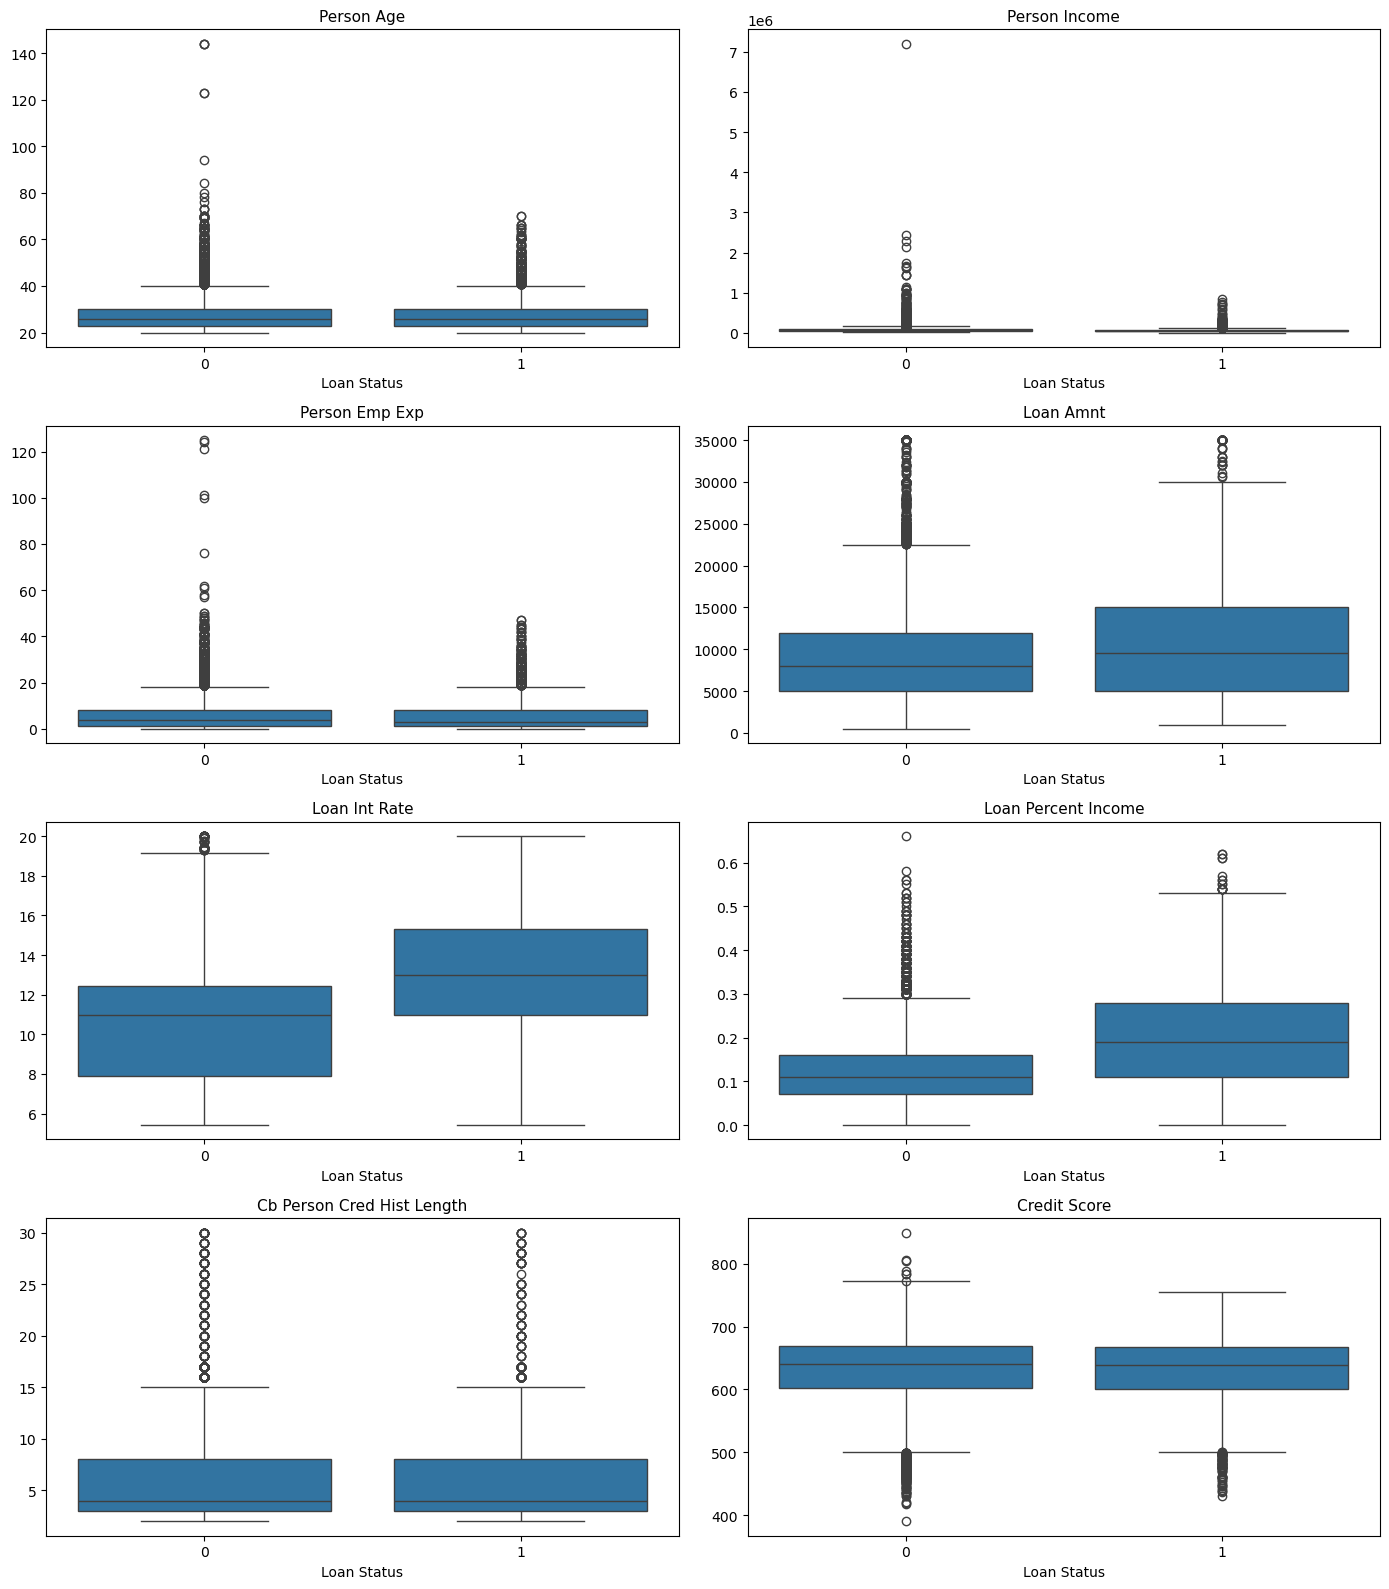

In [16]:
# Numerical Variables vs Loan Status
nrows = 4
ncols = 2

plt.figure(figsize=(14, 16))

for idx, col in enumerate(num_cols, start=1):
    plt.subplot(nrows, ncols, idx)
    sns.boxplot(data=train,x='loan_status',y=col)

    plt.title(col.replace("_", " ").title(), fontsize=11)
    plt.xlabel("Loan Status")
    plt.ylabel("")

plt.tight_layout()
plt.show()

### Key Observations

- Defaulted loans generally have higher loan amounts and interest rates than non-defaulted loans.
- Borrowers who default tend to have a higher loan-to-income ratio.
- Age, income, employment experience, credit history length, and credit score show relatively small differences between the two groups.
- Several numerical variables contain outliers across both loan status categories.

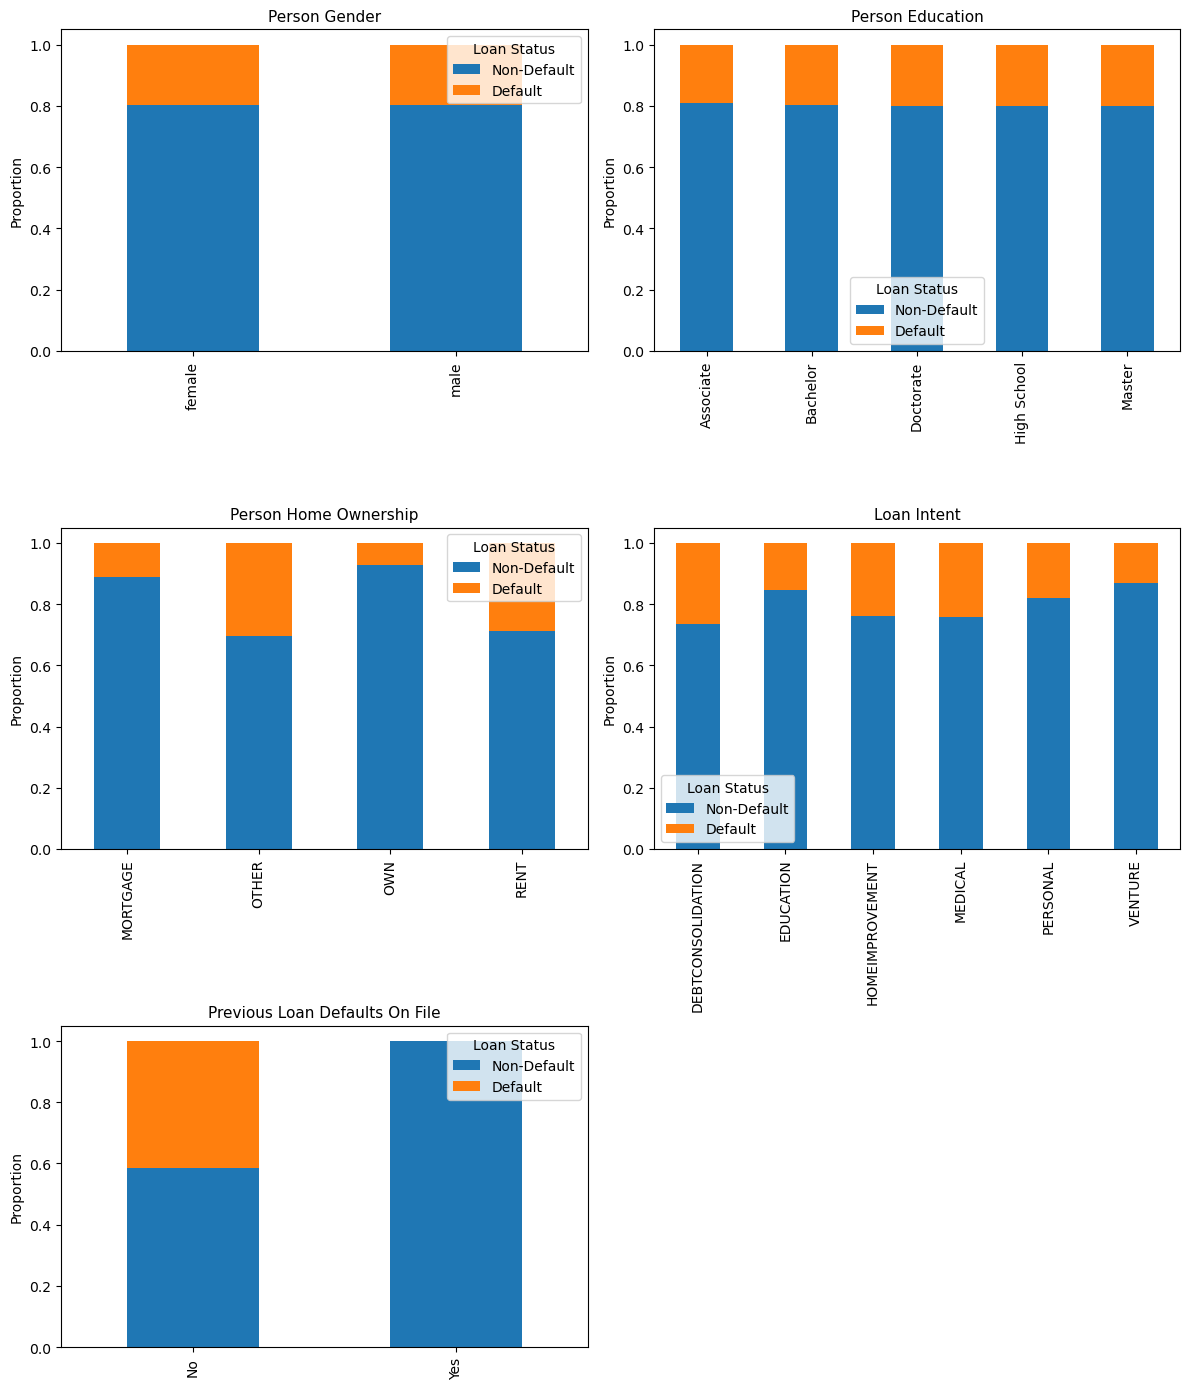

In [17]:
# Categorical Variables vs Loan Status
nrows = 3
ncols = 2
plt.figure(figsize=(12, 14))

for idx, col in enumerate(cat_cols, start=1):
    plt.subplot(nrows, ncols, idx)
    pd.crosstab( train[col], train["loan_status"], normalize="index").plot(kind="bar", stacked=True, ax=plt.gca())

    plt.title(col.replace("_", " ").title(), fontsize=11)
    plt.xlabel("")
    plt.ylabel("Proportion")
    plt.legend(["Non-Default", "Default"], title="Loan Status")

plt.tight_layout()
plt.show()

### Key Observations

- Default rates are similar across male and female applicants.
- Education level shows only minor differences in default rates.
- Applicants with RENT or OTHER home ownership have higher default rates than those with OWN or MORTGAGE.
- Debt Consolidation, Medical, and Home Improvement loans show relatively higher default rates, while Venture loans have the lowest default rate.
- Borrowers without a previous loan default are much more likely to default than those with a previous default on file.

### 5.4 Correlation Analysis

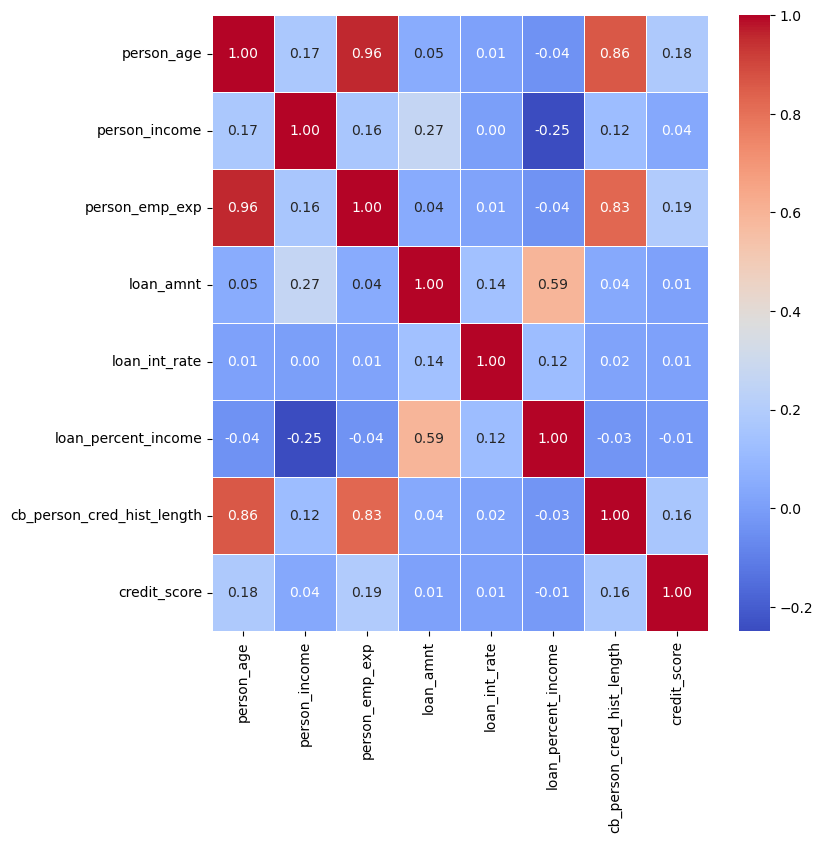

<Figure size 640x480 with 0 Axes>

In [18]:
corr=train[num_cols].corr()
plt.figure(figsize=(8,8))

sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.show()
plt.tight_layout()
plt.show()

### Key Observations
- Person age and employment experience are highly positively correlated (**r = 0.96**).
- Age and credit history length also show a strong positive correlation (**r = 0.86**).
- Loan amount has a moderate positive correlation with loan percentage of income (**r = 0.59**).
- Most other numerical variables show weak correlations, indicating limited multicollinearity.

## 6.Statistical Analysis

Statistical hypothesis testing is performed to determine whether the observed differences between defaulted and non-defaulted borrowers are statistically significant.

### 6.1 Mann–Whitney U Test
The Mann–Whitney U test is a non-parametric statistical test used to compare the distributions of numerical variables between two independent groups. It is appropriate when the data may not follow a normal distribution.

In [19]:
from scipy.stats import mannwhitneyu
results = []

for col in num_cols:
    default = train.loc[train["loan_status"] == 1, col]
    non_default = train.loc[train["loan_status"] == 0, col]

    statistic, p_value = mannwhitneyu(default,non_default,alternative="two-sided")

    results.append({
        "Feature": col,
        "Statistic": statistic,
        "P-Value": p_value,
        "Result": "Significant" if p_value < 0.05 else "Not Significant"
    })


mw_results = pd.DataFrame(results)

mw_results = mw_results.sort_values("P-Value").reset_index(drop=True)
mw_results.style.format({
    "Statistic": "{:.2f}",
    "P-Value": "{:.2e}"
})

,Feature,Statistic,P-Value,Result
0,person_income,63705802.50,0.00e+00,Significant
1,loan_int_rate,145715809.00,0.00e+00,Significant
2,loan_percent_income,148402746.00,0.00e+00,Significant
3,loan_amnt,114812330.50,5.50e-54,Significant
4,person_age,96942090.00,2.27e-13,Significant
5,cb_person_cred_hist_length,97779483.00,2.96e-10,Significant
6,person_emp_exp,98551259.50,1.19e-07,Significant
7,credit_score,101039810.50,3.68e-02,Significant


### Key Observations

- All numerical variables show statistically significant differences between defaulted and non-defaulted borrowers (p < 0.05).
- Loan amount, interest rate, and loan percentage of income exhibit the strongest differences between the two groups.
- Credit score is statistically significant; however, the visual difference between the groups is relatively small.
- These findings support the inclusion of numerical features in predictive modeling.

### 6.2 Chi-Square Test
The Chi-Square test of independence is used to determine whether categorical variables are significantly associated with loan default status.

In [20]:
from scipy.stats import chi2_contingency
results = []
for col in cat_cols:
    contingency_table = pd.crosstab(train[col],train["loan_status"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    results.append({
        "Feature": col,
        "Chi-Square": chi2,
        "P-Value": p_value,
        "Result": "Significant" if p_value < 0.05 else "Not Significant"
    })

chi_results = pd.DataFrame(results)

chi_results.sort_values("P-Value").reset_index(drop=True)
chi_results.style.format({
    "Chi-Square": "{:.2f}",
    "P-Value": "{:.2e}"
})

,Feature,Chi-Square,P-Value,Result
0,person_gender,0.01,9.33e-01,Not Significant
1,person_education,3.50,4.77e-01,Not Significant
2,person_home_ownership,1892.76,0.00e+00,Significant
3,loan_intent,561.46,4.29e-119,Significant
4,previous_loan_defaults_on_file,9681.84,0.00e+00,Significant


### Key Observations

- Home ownership, loan purpose, and previous loan default history are significantly associated with loan default status (p < 0.05).
- Gender and education level do not show a statistically significant association with loan default.
- Previous loan default history exhibits the strongest association with the target variable based on the Chi-Square statistic.
- Statistically significant categorical variables may contribute valuable information for predictive modeling.

## 7.Feature Engineering

In [21]:
train.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [22]:
#Income Group
train['income_group'] = pd.qcut(train['person_income'],q=4,
    labels=['Low', 'Medium', 'High', 'Very High'])

test['income_group'] = pd.qcut(test['person_income'],q=4,
    labels=['Low', 'Medium', 'High', 'Very High'])

**Reason:**
Created to categorize applicants into income segments and analyze how loan default varies across income levels.

In [23]:
#Credit Category
train['credit_category'] = pd.cut(train['credit_score'],
    bins=[300, 580, 670, 740, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent'])

test['credit_category'] = pd.cut(
    test['credit_score'],
    bins=[300, 580, 670, 740, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent'])

**Reason:**
Created to convert raw credit scores into standard credit rating categories commonly used in lending decisions.

In [24]:
#Employment Experience Group
train['experience_group'] = pd.cut(train['person_emp_exp'],
    bins=[0, 2, 5, 10, 100],
    labels=['New', 'Junior', 'Mid', 'Experienced'])

test['experience_group'] = pd.cut(test['person_emp_exp'],
    bins=[0, 2, 5, 10, 100],
    labels=['New', 'Junior', 'Mid', 'Experienced'])

**Reason:**
Created to group applicants by work experience and evaluate whether employment stability influences loan default risk.

## 8. Data Preprocessing
Data preprocessing prepares the dataset for machine learning by transforming the data into a suitable format. This includes separating the target variable, outlier treatment,encoding categorical features, aligning train and test datasets, and applying feature scaling where necessary.

### 8.1 Separate Features and Target
The target variable (`loan_status`) was separated from the predictor variables for model training and evaluation.

In [25]:
X_train = train.drop(columns='loan_status')
y_train = train['loan_status']

X_test = test.drop(columns='loan_status')
y_test = test['loan_status']

print("Training Features :", X_train.shape)
print("Training Target   :", y_train.shape)
print("Testing Features  :", X_test.shape)
print("Testing Target    :", y_test.shape)

Training Features : (35999, 16)
Training Target   : (35999,)
Testing Features  : (9001, 16)
Testing Target    : (9001,)


### 8.2 Outlier Treatment

Extreme values were capped using the Interquartile Range (IQR) method to reduce their influence while preserving the observations for model training.

In [26]:
outlier_cols = [
    'person_age',
    'person_income',
    'person_emp_exp']

for col in outlier_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

In [27]:
X_train[outlier_cols].describe()

,person_age,person_income,person_emp_exp
count,35999.000000,35999.000000,35999.000000
mean,27.473833,76389.151393,5.219048
std,5.220356,38297.191282,5.238254
min,20.000000,8000.000000,0.000000
25%,23.000000,47877.500000,1.000000
50%,26.000000,67545.000000,4.000000
75%,30.000000,96824.500000,8.000000
max,40.500000,170245.000000,18.500000


### Observation

- Extreme values in age, income, and employment experience were capped using the IQR method while retaining all observations.

## 8.3 Encode Categorical Variables
Categorical variables were converted into numerical format using One-Hot Encoding to make them suitable for machine learning models.

In [28]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

print("Encoded Training Shape :", X_train.shape)
print("Encoded Testing Shape  :", X_test.shape)

Encoded Training Shape : (35999, 31)
Encoded Testing Shape  : (9001, 31)


## 8.4 Align Train and Test Features
The training and testing datasets were aligned to ensure they contain the same set of features after encoding.

In [29]:
train,test= train.align(test,join='left',axis=1,fill_value=0)

## 8.5 Feature Scaling
Numerical features were standardized using `StandardScaler` to ensure they are on a comparable scale, particularly for Logistic Regression.

In [30]:
from sklearn.preprocessing import StandardScaler
# Numerical columns to scale
num_features = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score']

scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


# 9. Model Building
This section develops and evaluates multiple machine learning models to predict loan default. Logistic Regression is used as the baseline model, followed by Decision Tree, Random Forest, and XGBoost for comparison.

## 9.1 Logistic Regression (Baseline Model)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report

lr_model = LogisticRegression(random_state=42,max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8860

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6109
           1       0.88      0.74      0.81      2892

    accuracy                           0.89      9001
   macro avg       0.89      0.85      0.86      9001
weighted avg       0.89      0.89      0.88      9001



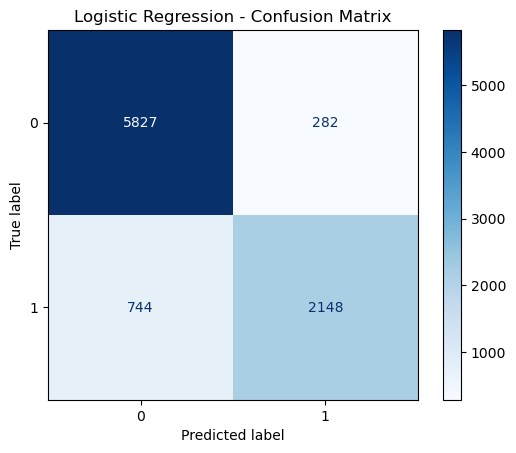

In [32]:
### Confusion Matrix :summarizes the model's prediction performance by comparing the actual and predicted loan status.
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions( y_test, y_pred_lr,cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

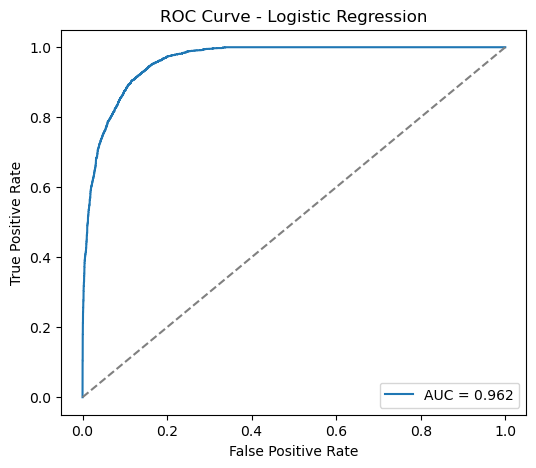

ROC-AUC Score: 0.9622


In [33]:
### ROC Curve:It evaluates the model's ability to distinguish between default and non-default loan applicants across different classification thresholds.
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

### Observations

- Logistic Regression achieved an accuracy of **88.6%** and an ROC-AUC score of **0.962**.
- The model effectively distinguishes between default and non-default borrowers.
- It provides a strong baseline for comparison with tree-based ensemble models.

## 9.2 Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]


print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8922

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      6109
           1       0.86      0.79      0.82      2892

    accuracy                           0.89      9001
   macro avg       0.88      0.86      0.87      9001
weighted avg       0.89      0.89      0.89      9001



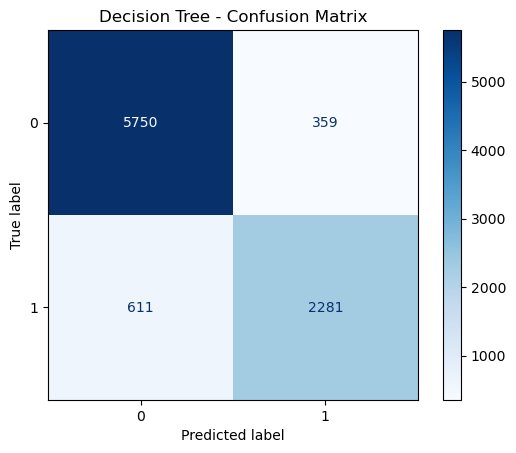

In [35]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_dt, cmap="Blues")

plt.title("Decision Tree - Confusion Matrix")
plt.show()

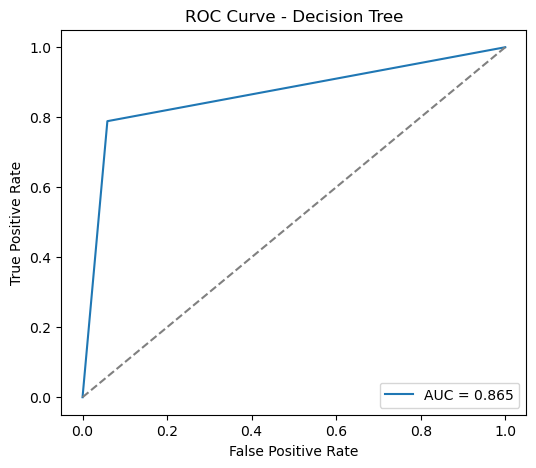

ROC-AUC Score: 0.8650


In [36]:
### ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)
auc_score_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score_dt:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")

plt.show()

print(f"ROC-AUC Score: {auc_score_dt:.4f}")

### Observations

- Decision Tree achieved an accuracy of **89.2%**.
- The model improved recall for default loans compared to Logistic Regression, identifying more defaulters correctly.
- However, the ROC-AUC score (**0.865**) is lower than Logistic Regression, indicating weaker overall class discrimination.

## 9.3 Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9088

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.98      0.94      6109
           1       0.95      0.75      0.84      2892

    accuracy                           0.91      9001
   macro avg       0.92      0.87      0.89      9001
weighted avg       0.91      0.91      0.91      9001



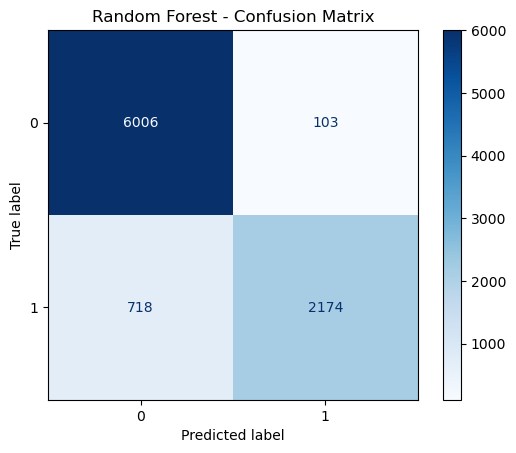

In [46]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_rf, cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.show()

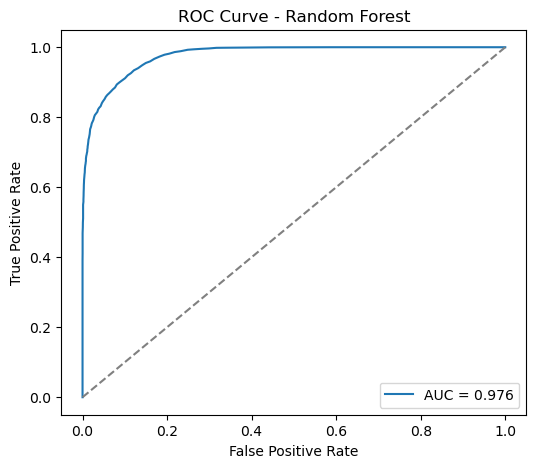

ROC-AUC Score: 0.9763


In [47]:
### ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc_score_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score_rf:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")

plt.show()

print(f"ROC-AUC Score: {auc_score_rf:.4f}")

### Observations
- Random Forest achieved an accuracy of 90.9%, outperforming both Logistic Regression and Decision Tree.
- The model achieved higher precision for default loans while maintaining strong overall classification performance.
- The ROC-AUC score (0.976) indicates excellent class discrimination, making Random Forest the best-performing model among those evaluated so far.

## 9.4 XGBoost

In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(random_state=42,eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9180

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6109
           1       0.95      0.78      0.86      2892

    accuracy                           0.92      9001
   macro avg       0.93      0.88      0.90      9001
weighted avg       0.92      0.92      0.92      9001



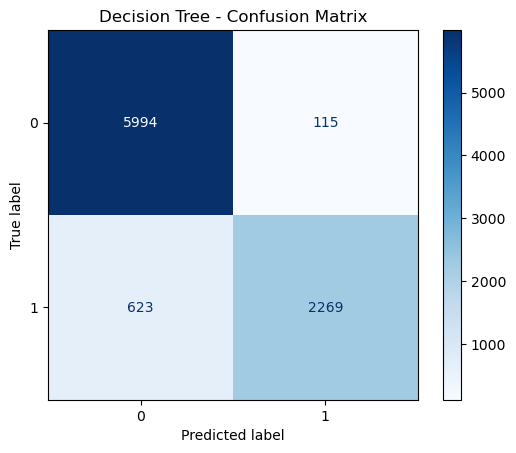

In [41]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_xgb, cmap="Blues")

plt.title("Decision Tree - Confusion Matrix")
plt.show()

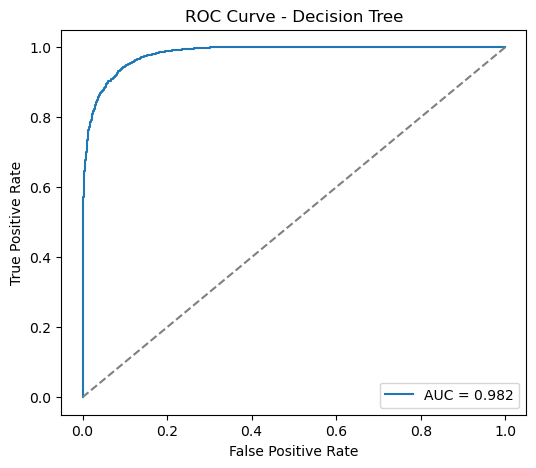

ROC-AUC Score: 0.9817


In [42]:
### ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
auc_score_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score_xgb:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")

plt.show()

print(f"ROC-AUC Score: {auc_score_xgb:.4f}")

**Observations**
- XGBoost achieved the highest accuracy (91.8%) among all the models.
- The model achieved high precision (0.95) for default loans while maintaining strong overall performance.
- The ROC-AUC score (0.982) indicates outstanding ability to distinguish between default and non-default borrowers, making XGBoost the best-performing model.

### Compare Models

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8860,0.8840,0.7427,0.8072,0.9622
1,Decision Tree,0.8922,0.8640,0.7887,0.8247,0.8650
2,Random Forest,0.9088,0.9548,0.7517,0.8412,0.9763
3,XGBoost,0.9180,0.9518,0.7846,0.8601,0.9817


- Among the four models evaluated, XGBoost achieved the best overall performance. It recorded the highest accuracy (91.8%), F1-score (0.8601), and ROC-AUC score (0.9817), demonstrating excellent ability to distinguish between default and non-default borrowers.
- Therefore, XGBoost was selected as the final model for loan default prediction due to its superior predictive performance and balanced classification results.

### Feature Importance (XGBoost)

In [44]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_})

top_features = feature_importance.sort_values('Importance',ascending=False).head(10)

print(top_features)

                               Feature  Importance
21  previous_loan_defaults_on_file_Yes    0.804306
5                  loan_percent_income    0.028544
15          person_home_ownership_RENT    0.024585
14           person_home_ownership_OWN    0.023906
20                 loan_intent_VENTURE    0.015062
4                        loan_int_rate    0.014826
17         loan_intent_HOMEIMPROVEMENT    0.012054
1                        person_income    0.009659
18                 loan_intent_MEDICAL    0.007344
19                loan_intent_PERSONAL    0.007208


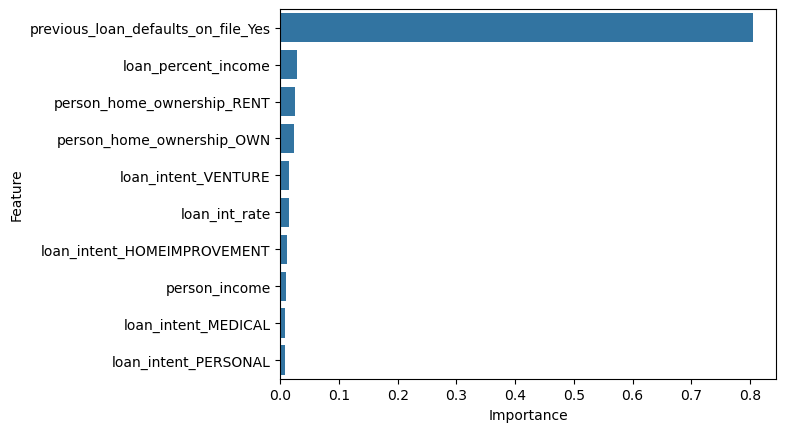

In [45]:
sns.barplot(data=top_features, x='Importance', y='Feature')
plt.show()

### Observations

- Previous loan defaults on file is the most influential feature, contributing significantly more than all other variables.
- Loan percent income, home ownership, loan intent, loan interest rate, and income also contribute to predicting loan default.
- The feature importance results indicate that an applicant's credit history and repayment behavior are the strongest indicators of future loan default.

## 10. Conclusion

- The dataset was explored through EDA, statistical testing, and feature engineering to understand factors influencing loan default.
- Data preprocessing techniques, including outlier treatment and categorical encoding, were applied before model building.
- Four machine learning models were developed and compared: Logistic Regression, Decision Tree, Random Forest, and XGBoost.
- Among all models, XGBoost achieved the best predictive performance with an accuracy of **91.8%** and a **ROC-AUC score of 0.9817**.
- The developed model can effectively identify high-risk borrowers and support better loan approval decisions, helping financial institutions reduce default risk.

## 11.Business Recommendations

- Prioritize additional verification for applicants with previous loan defaults.
- Closely monitor borrowers with high loan-to-income ratios.
- Consider credit score and loan interest rate together during loan approval decisions.
- Apply risk-based lending strategies for applicants with higher default probabilities.